# Radix tree structure & access statistics

Loads experiment JSON under `../results/page_size_json_<dataset>/` (falls back to `page_size_json/`). Set env `KV_SIM_PLOT_DATASET` to match experiments `--dataset`. Each file contains `metrics.tree_depth_histogram` (node count per depth), `metrics.tree_access_by_depth` (aggregate access stats), and `metrics.access_percentiles_by_depth` (min / p50 / p90 / p99 / max of `access_count` per depth — requires re-running simulations after metrics update).

In [13]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROOT = Path("..").resolve()
RES = ROOT / "results"
DATASET = os.environ.get("KV_SIM_PLOT_DATASET", "loogle")


def json_subdir(base: str) -> str:
    """Prefer ``{base}_{DATASET}`` if that directory exists (matches experiment defaults)."""
    named = RES / f"{base}_{DATASET}"
    if named.is_dir():
        return f"{base}_{DATASET}"
    return base

In [14]:
def load_result_jsons(subdir: str = "page_size_json") -> list[dict]:
    d = RES / subdir
    if not d.is_dir():
        print(f"Missing {d}")
        return []
    out = []
    for p in sorted(d.glob("*.json")):
        with p.open(encoding="utf-8") as f:
            row = json.load(f)
        row["_path"] = p.name
        out.append(row)
    print(f"Loaded {len(out)} JSON files from {d}")
    return out

In [15]:
def depth_hist_to_series(h: dict) -> pd.Series:
    if not h:
        return pd.Series(dtype=float)
    idx = sorted(h.keys(), key=lambda x: int(x))
    return pd.Series({int(k): int(h[k]) for k in idx})


def access_agg_to_frame(acc: dict) -> pd.DataFrame:
    if not acc:
        return pd.DataFrame()
    rows = []
    for k in sorted(acc.keys(), key=lambda x: int(x)):
        r = {"depth": int(k), **acc[k]}
        rows.append(r)
    return pd.DataFrame(rows)


def percentiles_to_frame(pct: dict) -> pd.DataFrame:
    if not pct:
        return pd.DataFrame()
    rows = [{"depth": int(k), **v} for k, v in sorted(pct.items(), key=lambda kv: int(kv[0]))]
    return pd.DataFrame(rows)

## 1. Node count vs depth (tree shape)

One panel per `(dataset, strategy)`; colored lines = different `page_size` (or pick one run).

Loaded 10 JSON files from /data/howarli/dev/llm_prefix_caching/results/page_size_json_loogle


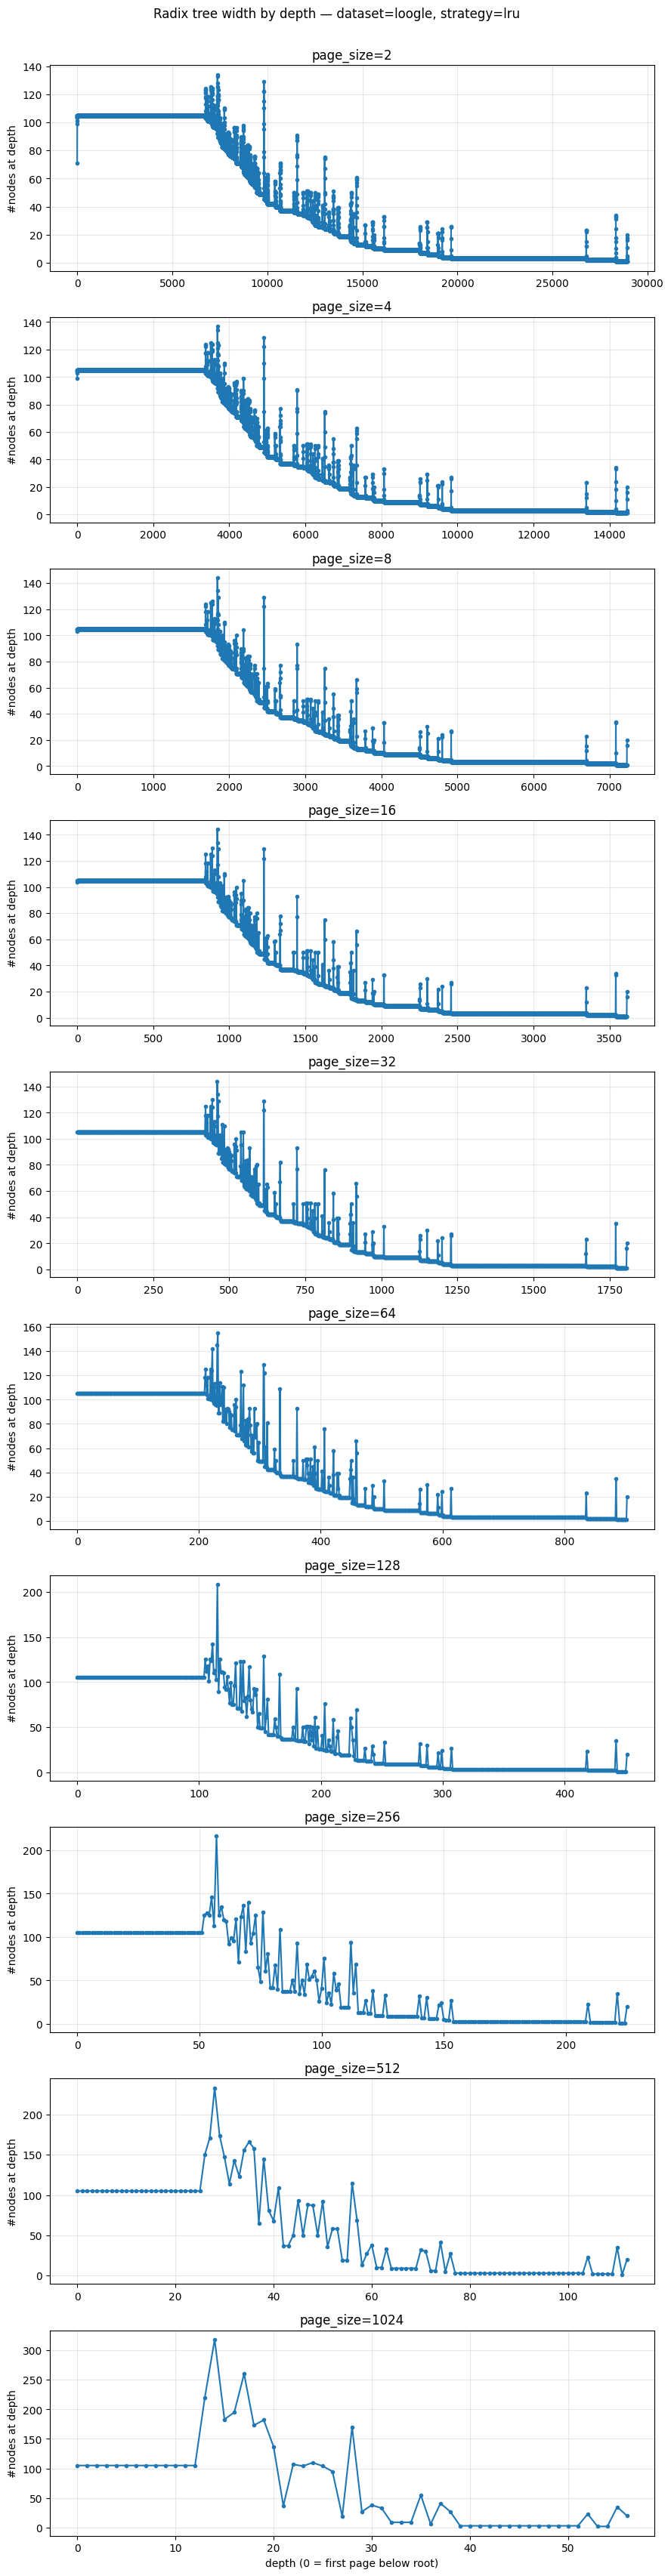

In [16]:
rows = load_result_jsons(json_subdir("page_size_json"))
if not rows:
    rows = load_result_jsons(json_subdir("eviction_json"))
if not rows:
    rows = load_result_jsons(json_subdir("ordering_json"))

if rows:
    by_key: dict[tuple, list[tuple[int, pd.Series]]] = {}
    for row in rows:
        m = row.get("metrics") or {}
        h = m.get("tree_depth_histogram") or {}
        if not h:
            continue
        ds = row.get("dataset", "?")
        st = row.get("strategy", "?")
        ps = int(row.get("page_size", -1))
        key = (ds, st)
        by_key.setdefault(key, []).append((ps, depth_hist_to_series(h)))

    for (ds, st), series_list in sorted(by_key.items()):
        series_list = sorted(series_list, key=lambda x: x[0])
        n_ps = len(series_list)
        if not n_ps:
            continue
        fig, axes = plt.subplots(
            n_ps, 1, figsize=(9, max(3.2, 3.4 * n_ps)), squeeze=False
        )
        axs = axes.ravel()
        for ax, (ps, ser) in zip(axs, series_list):
            ax.plot(ser.index, ser.values, "o-", ms=3, color="C0")
            ax.set_ylabel("#nodes at depth")
            ax.set_title(f"page_size={ps}")
            ax.grid(True, alpha=0.3)
        axs[-1].set_xlabel("depth (0 = first page below root)")
        fig.suptitle(
            f"Radix tree width by depth — dataset={ds}, strategy={st}",
            y=1.002,
        )
        plt.tight_layout()
        plt.show()

Loaded 10 JSON files from /data/howarli/dev/llm_prefix_caching/results/page_size_json_loogle


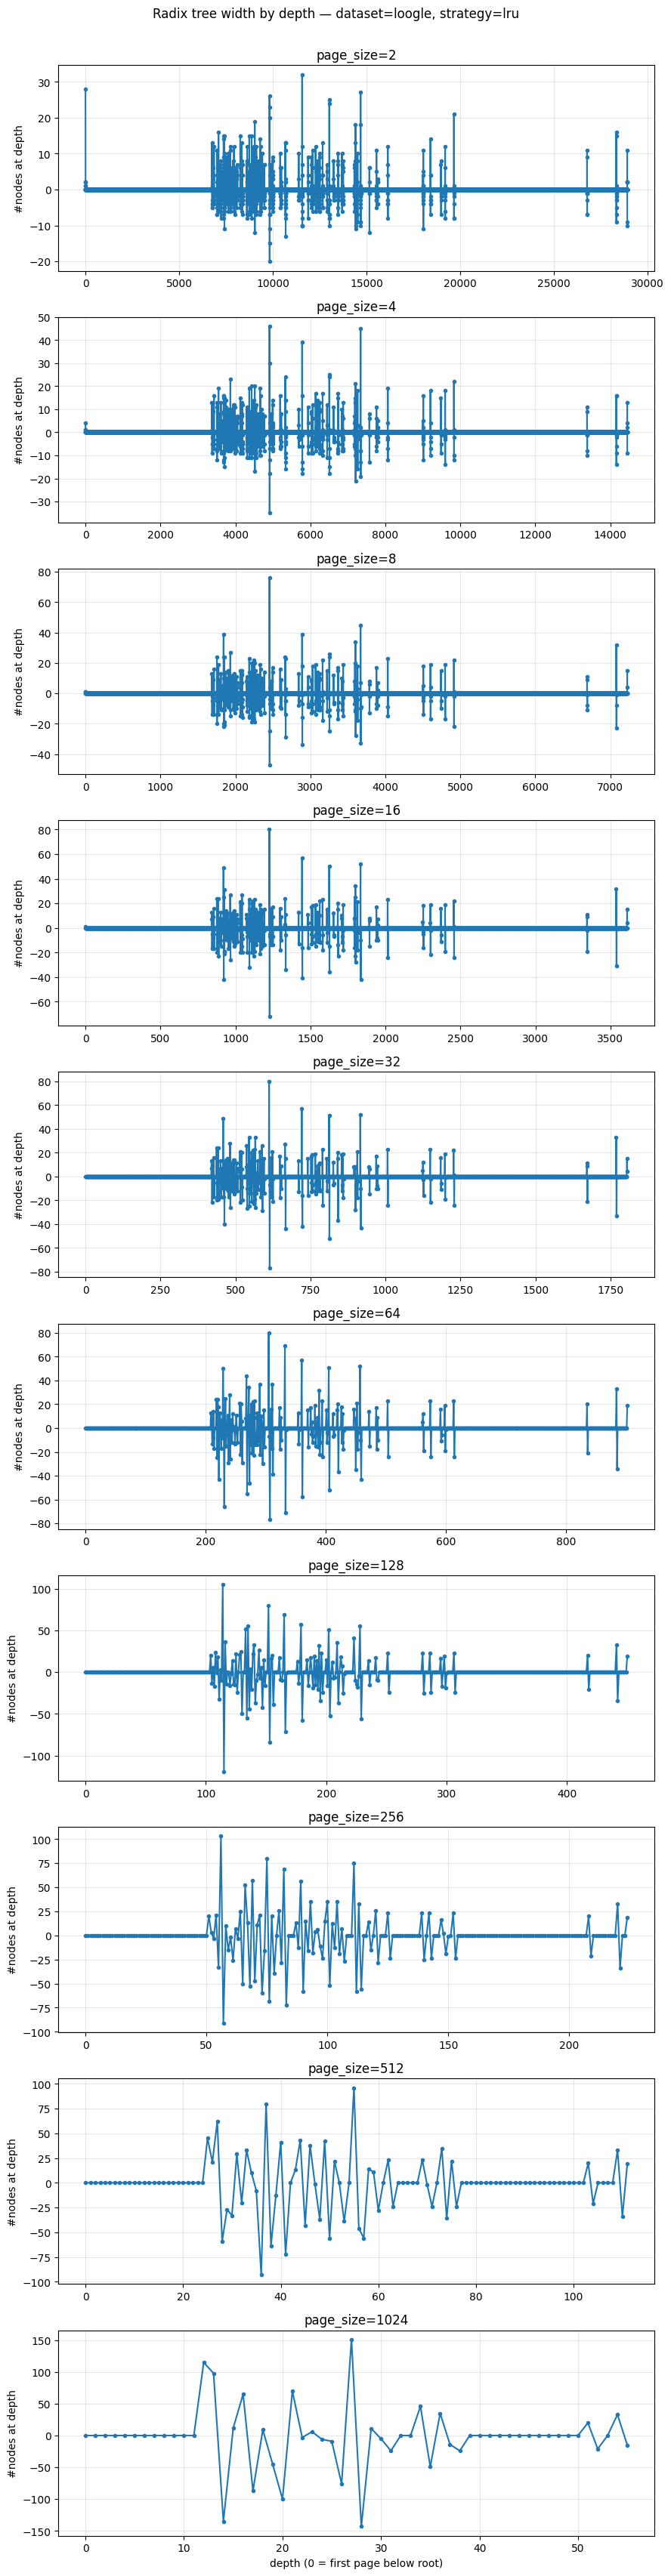

In [18]:
rows = load_result_jsons(json_subdir("page_size_json"))
if not rows:
    rows = load_result_jsons(json_subdir("eviction_json"))
if not rows:
    rows = load_result_jsons(json_subdir("ordering_json"))

if rows:
    by_key: dict[tuple, list[tuple[int, pd.Series]]] = {}
    for row in rows:
        m = row.get("metrics") or {}
        h = m.get("tree_depth_histogram") or {}
        if not h:
            continue
        ds = row.get("dataset", "?")
        st = row.get("strategy", "?")
        ps = int(row.get("page_size", -1))
        key = (ds, st)
        by_key.setdefault(key, []).append((ps, depth_hist_to_series(h)))

    for (ds, st), series_list in sorted(by_key.items()):
        series_list = sorted(series_list, key=lambda x: x[0])
        n_ps = len(series_list)
        if not n_ps:
            continue
        fig, axes = plt.subplots(
            n_ps, 1, figsize=(9, max(3.2, 3.4 * n_ps)), squeeze=False
        )
        axs = axes.ravel()
        for ax, (ps, ser) in zip(axs, series_list):
            v = np.diff(ser.values)
            ax.plot(ser.index[:-1], v, "o-", ms=3, color="C0")
            ax.set_ylabel("#nodes at depth")
            ax.set_title(f"page_size={ps}")
            ax.grid(True, alpha=0.3)
        axs[-1].set_xlabel("depth (0 = first page below root)")
        fig.suptitle(
            f"Radix tree width by depth — dataset={ds}, strategy={st}",
            y=1.002,
        )
        plt.tight_layout()
        plt.show()

## 2. Mean / total access by depth

Uses `tree_access_by_depth`: `mean_access` and `sum_access` per depth (single run — pick smallest `page_size` file or adjust filter).

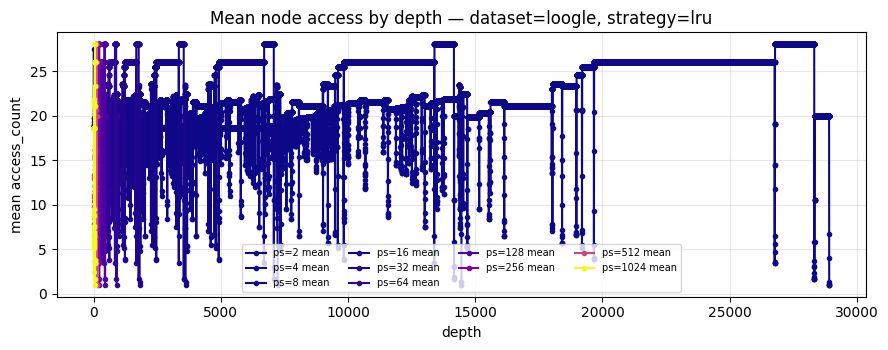

In [ ]:
if rows:
    by_key2: dict[tuple, list[tuple[int, pd.DataFrame]]] = {}
    for row in rows:
        m = row.get("metrics") or {}
        acc = m.get("tree_access_by_depth") or {}
        if not acc:
            continue
        ds = row.get("dataset", "?")
        st = row.get("strategy", "?")
        ps = int(row.get("page_size", -1))
        key = (ds, st)
        by_key2.setdefault(key, []).append((ps, access_agg_to_frame(acc)))

    n2 = len(by_key2)
    if n2:
        fig, axes = plt.subplots(n2, 1, figsize=(9, max(3.2, 3.6 * n2)), squeeze=False)
        cmap = plt.get_cmap("plasma")
        for ax, ((ds, st), frames) in zip(axes.ravel(), sorted(by_key2.items())):
            frames = sorted(frames, key=lambda x: x[0])
            pss = [x[0] for x in frames]
            norm = plt.Normalize(min(pss), max(pss) if max(pss) > min(pss) else min(pss) + 1)
            for ps, df in frames:
                if df.empty:
                    continue
                c = cmap(norm(ps))
                ax.plot(df["depth"], df["mean_access"], "o-", ms=3, color=c, label=f"ps={ps} mean")
            ax.set_xlabel("depth")
            ax.set_ylabel("mean access_count")
            ax.set_title(f"Mean node access by depth — dataset={ds}, strategy={st}")
            ax.legend(fontsize=7, ncol=4, loc="best")
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 3. Access-count band (p50–p90) by depth

Needs `access_percentiles_by_depth` in JSON (re-run experiments after updating `src/metrics.py`). Shows spread of `access_count` among nodes at each depth.

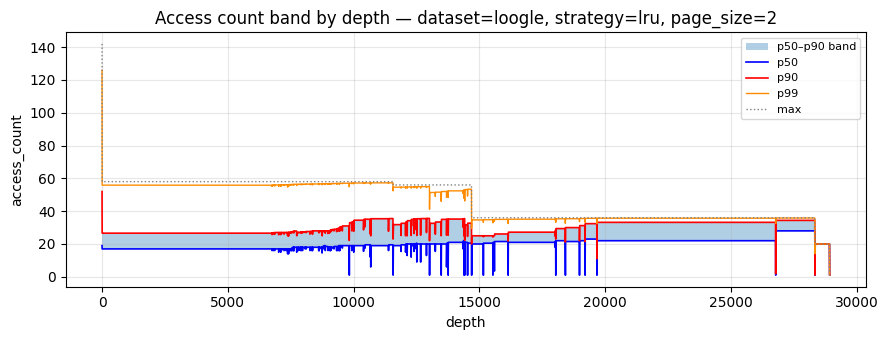

In [ ]:
if rows:
    # Pick one configuration: smallest page_size per (dataset, strategy)
    pick: dict[tuple, dict] = {}
    for row in rows:
        m = row.get("metrics") or {}
        pct = m.get("access_percentiles_by_depth") or {}
        if not pct:
            continue
        key = (row.get("dataset"), row.get("strategy"))
        ps = int(row.get("page_size", 10**9))
        if key not in pick or ps < int(pick[key].get("page_size", 10**9)):
            pick[key] = row

    if not pick:
        print("No access_percentiles_by_depth in JSON — re-run simulations to refresh metrics.")
    else:
        n3 = len(pick)
        fig, axes = plt.subplots(n3, 1, figsize=(9, max(3.2, 3.5 * n3)), squeeze=False)
        for ax, ((ds, st), row) in zip(axes.ravel(), sorted(pick.items())):
            m = row["metrics"]
            df = percentiles_to_frame(m.get("access_percentiles_by_depth") or {})
            if df.empty:
                continue
            x = df["depth"]
            ax.fill_between(x, df["p50"], df["p90"], alpha=0.35, label="p50–p90 band")
            ax.plot(x, df["p50"], "b-", lw=1.2, label="p50")
            ax.plot(x, df["p90"], "r-", lw=1.2, label="p90")
            if "p99" in df.columns:
                ax.plot(x, df["p99"], color="darkorange", lw=1, label="p99")
            if "max" in df.columns:
                ax.plot(x, df["max"], ":", color="gray", lw=1, label="max")
            ps = row.get("page_size")
            ax.set_xlabel("depth")
            ax.set_ylabel("access_count")
            ax.set_title(
                f"Access count band by depth — dataset={ds}, strategy={st}, page_size={ps}"
            )
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()